<a href="https://colab.research.google.com/github/pardeepkaur-cs/real-time-login-monitoring-ml/blob/main/real_time_login_monitoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Real-Time Login Monitoring & Alert System

## Objective
Build a hybrid system that combines machine learning and rule-based logic to detect suspicious login activity in real-time.

## Problem
Traditional systems either rely only on rules or only on machine learning. This project combines both to improve detection accuracy.

## Approach
- Simulated login stream
- ML prediction (Decision Tree)
- Risk score calculation
- Alert generation

In [1]:
import pandas as pd

data = {
"login_hour":[9,10,11,3,14,22,8,2],
"device":[1,1,1,2,1,2,1,2],
"download_MB":[5,8,3,200,2,50,1,300],
"location":[0,0,0,1,0,1,0,1],
"suspicious":[0,0,0,1,0,1,0,1]
}

df = pd.DataFrame(data)
df

,login_hour,device,download_MB,location,suspicious
0,9,1,5,0,0
1,10,1,8,0,0
2,11,1,3,0,0
3,3,2,200,1,1
4,14,1,2,0,0
5,22,2,50,1,1
6,8,1,1,0,0
7,2,2,300,1,1


In [2]:
from sklearn.tree import DecisionTreeClassifier

X = df[["login_hour","device","download_MB","location"]]
y = df["suspicious"]

model = DecisionTreeClassifier()
model.fit(X,y)

DecisionTreeClassifier()

In [4]:
def risk_score(login_hour, device, download_MB, location):
    risk = 0

    if login_hour < 6 or login_hour > 22:
        risk += 30
    if download_MB > 100:
        risk += 30
    if device == 2:
        risk += 20
    if location == 1:
        risk += 20

    return risk

In [5]:
test_logins = [
    [2,2,250,1],
    [10,1,5,0],
    [23,2,180,1]
]

for login in test_logins:
    pred = model.predict([login])[0]
    risk = risk_score(*login)

    print("Login:", login)
    print("ML Prediction:", "Suspicious" if pred==1 else "Normal")
    print("Risk Score:", risk)

    if pred == 1 or risk > 60:
        print("🚨 ALERT: Suspicious Activity Detected\n")
    else:
        print("✅ Normal Activity\n")

Login: [2, 2, 250, 1]
ML Prediction: Suspicious
Risk Score: 100
🚨 ALERT: Suspicious Activity Detected

Login: [10, 1, 5, 0]
ML Prediction: Normal
Risk Score: 0
✅ Normal Activity

Login: [23, 2, 180, 1]
ML Prediction: Suspicious
Risk Score: 100
🚨 ALERT: Suspicious Activity Detected



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


## System Insight

This system combines machine learning predictions with rule-based risk scoring to improve detection reliability.

Such hybrid approaches are commonly used in real-world cybersecurity systems to reduce false positives and enhance decision-making.

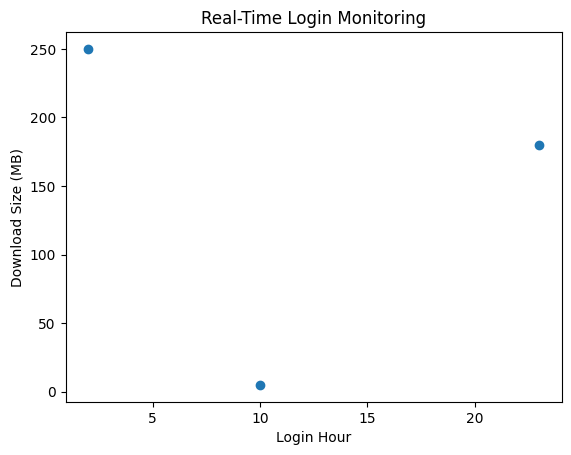

In [6]:
import matplotlib.pyplot as plt

# Example data for visualization
hours = [login[0] for login in test_logins]
downloads = [login[2] for login in test_logins]

plt.scatter(hours, downloads)

plt.xlabel("Login Hour")
plt.ylabel("Download Size (MB)")
plt.title("Real-Time Login Monitoring")

plt.show()

## System Workflow

1. User attempts login  
2. System captures login features (time, device, data usage, location)  
3. Machine learning model predicts behavior  
4. Risk score is calculated using rule-based logic  
5. If risk is high → system triggers alert  

This simulates a real-time cybersecurity monitoring system.

## Conclusion

This project demonstrates a hybrid cybersecurity system combining machine learning and rule-based logic for real-time anomaly detection.

Such systems are widely used in sensitive environments like healthcare, where both accuracy and interpretability are important.

Future improvements can include:
- Real-time streaming data integration
- Advanced machine learning models
- Deployment as a web-based monitoring system